<a href="https://colab.research.google.com/github/ShachiPradhan/-cognevance_Sales-Forecasting-System/blob/main/SalesForecastingSystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [25]:
import os

# Create all necessary folders for the project
os.makedirs('data', exist_ok=True)
os.makedirs('outputs', exist_ok=True)
os.makedirs('outputs/charts', exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [26]:
import os
import shutil

# 1. Create the 'data' folder
os.makedirs('data', exist_ok=True)

# 2. Move the uploaded file into the 'data' folder
shutil.move('Sample - Superstore.csv', 'data/Sample - Superstore.csv')

'data/Sample - Superstore.csv'

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Load dataset
df = pd.read_csv('data/Sample - Superstore.csv', encoding='latin-1')

# Basic exploration
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic stats:")
print(df.describe())

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   


In [28]:
# 1. Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

# 2. Drop rows with missing critical values
df = df.dropna(subset=['Order Date', 'Sales'])

# 3. Remove duplicates
df = df.drop_duplicates()

# 4. Handle outliers using IQR (optional)
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df['Sales'] >= lower) & (df['Sales'] <= upper)]

# 5. Feature engineering
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.strftime('%b')
df['Quarter'] = df['Order Date'].dt.quarter
df['Day_of_Week'] = df['Order Date'].dt.day_name()

print("Cleaned shape:", df.shape)
print("Date range:", df['Order Date'].min(), "to", df['Order Date'].max())

Cleaned shape: (8827, 26)
Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00


/tmp/ipykernel_1306/799738844.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly_sales, x='Year', y='Sales', palette='viridis')


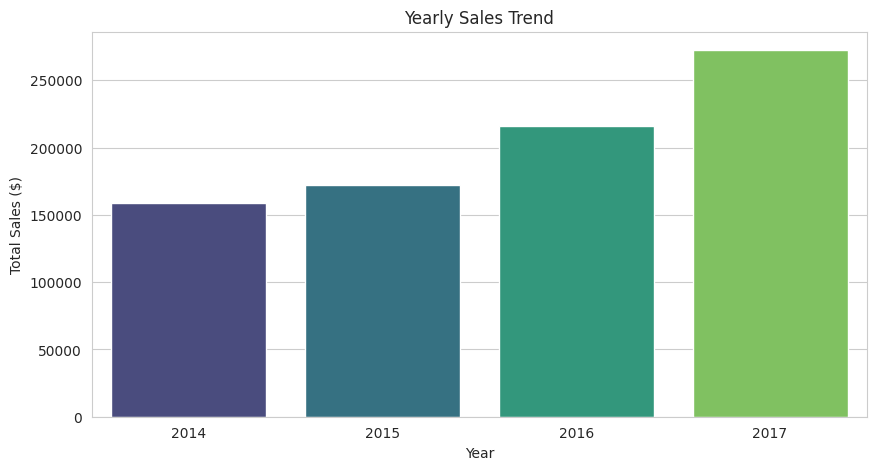

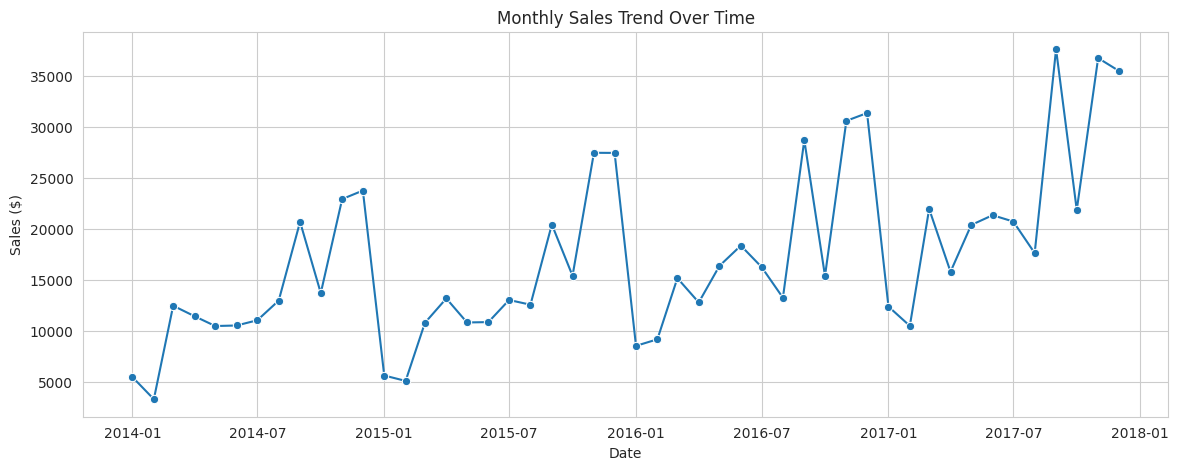

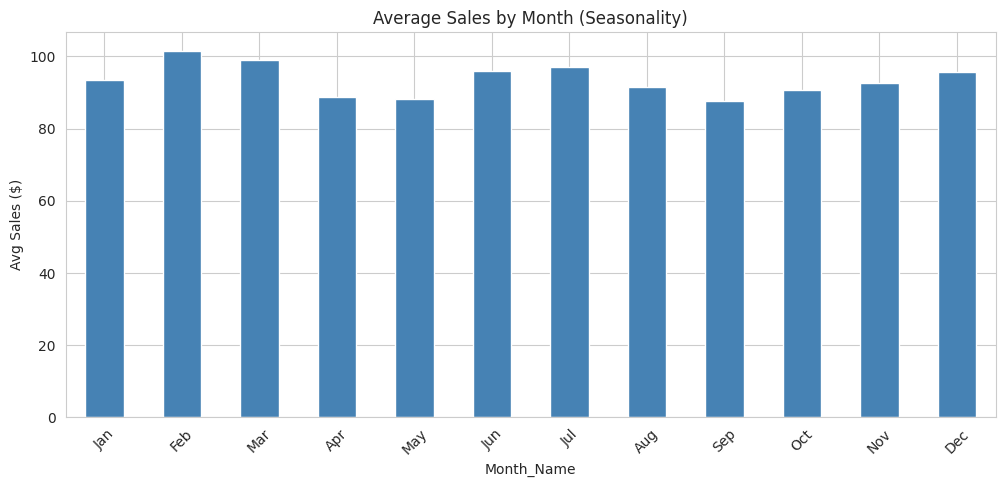

In [29]:
# --- Yearly Sales ---
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=yearly_sales, x='Year', y='Sales', palette='viridis')
plt.title('Yearly Sales Trend')
plt.ylabel('Total Sales ($)')
plt.savefig('yearly_sales.png', dpi=150, bbox_inches='tight')

plt.show()

# --- Monthly Sales Across Years ---
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(day=1))

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_sales, x='Date', y='Sales', marker='o')
plt.title('Monthly Sales Trend Over Time')
plt.ylabel('Sales ($)')
plt.xlabel('Date')
plt.savefig('yearly_sales.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Seasonality: Avg Sales by Month ---
seasonality = df.groupby('Month_Name')['Sales'].mean().reindex(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
)

plt.figure(figsize=(12, 5))
seasonality.plot(kind='bar', color='steelblue')
plt.title('Average Sales by Month (Seasonality)')
plt.ylabel('Avg Sales ($)')
plt.xticks(rotation=45)
plt.savefig('yearly_sales.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1306/1501217057.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = df.set_index('Order Date').resample('M')['Sales'].sum().reset_index()


        Date      Sales
0 2014-01-31   5438.155
1 2014-02-28   3263.672
2 2014-03-31  12452.536
3 2014-04-30  11421.191
4 2014-05-31  10456.715
Total months: 48


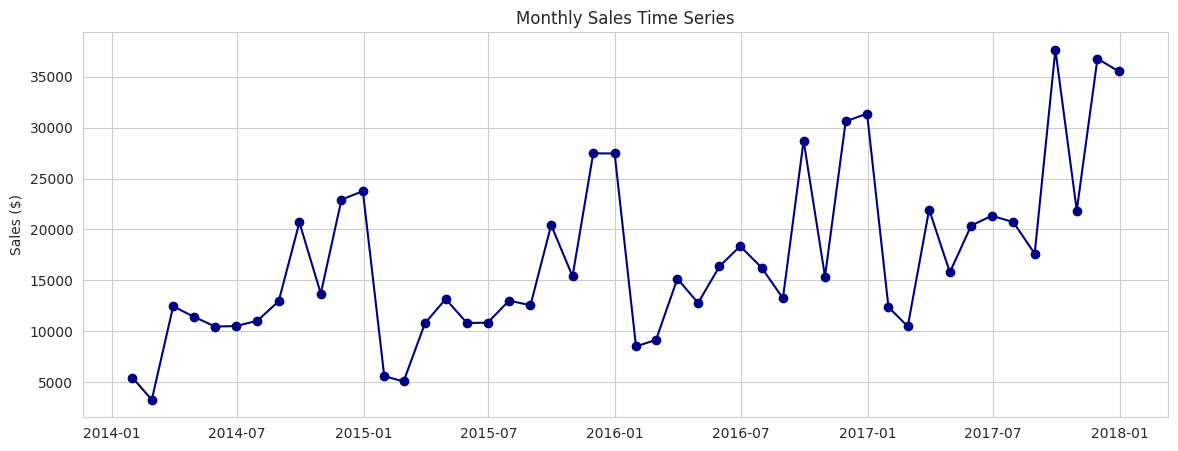

In [30]:
# Create monthly aggregated time series
ts = df.set_index('Order Date').resample('M')['Sales'].sum().reset_index()
ts.columns = ['Date', 'Sales']

print(ts.head())
print("Total months:", len(ts))

# Plot the time series
plt.figure(figsize=(14, 5))
plt.plot(ts['Date'], ts['Sales'], marker='o', color='navy')
plt.title('Monthly Sales Time Series')
plt.ylabel('Sales ($)')
plt.grid(True)
plt.savefig('yearly_sales.png', dpi=150, bbox_inches='tight')
plt.show()

MAE:  $3,873.75
RMSE: $5,019.14
R²:   0.6292


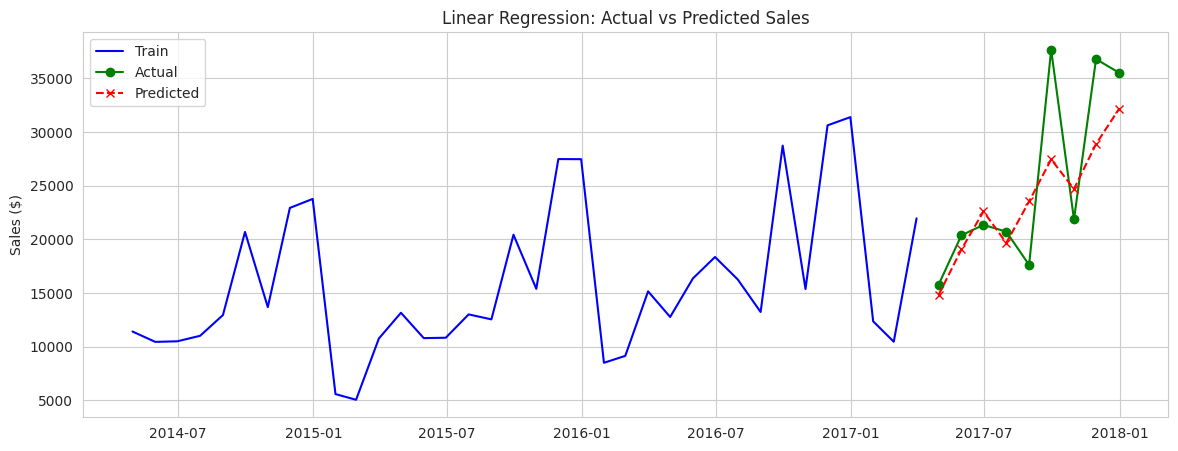

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Feature engineering for regression
ts_lr = ts.copy()
ts_lr['Month'] = ts_lr['Date'].dt.month
ts_lr['Year'] = ts_lr['Date'].dt.year
ts_lr['Quarter'] = ts_lr['Date'].dt.quarter
ts_lr['Time_Index'] = np.arange(len(ts_lr))  # trend feature

# Lag features (previous months' sales)
ts_lr['Lag_1'] = ts_lr['Sales'].shift(1)
ts_lr['Lag_2'] = ts_lr['Sales'].shift(2)
ts_lr['Lag_3'] = ts_lr['Sales'].shift(3)
ts_lr = ts_lr.dropna()

features = ['Time_Index', 'Month', 'Quarter', 'Lag_1', 'Lag_2', 'Lag_3']
X = ts_lr[features]
y = ts_lr['Sales']

# Train-test split (80/20, preserving order)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²:   {r2:.4f}")

# Plot predictions
plt.figure(figsize=(14, 5))
plt.plot(ts_lr['Date'][:split], y_train, label='Train', color='blue')
plt.plot(ts_lr['Date'][split:], y_test, label='Actual', color='green', marker='o')
plt.plot(ts_lr['Date'][split:], y_pred, label='Predicted', color='red', linestyle='--', marker='x')
plt.title('Linear Regression: Actual vs Predicted Sales')
plt.ylabel('Sales ($)')
plt.legend()
plt.savefig('yearly_sales.png', dpi=150, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.13/dist-packages/prophet/forecaster.py:2206: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


Prophet MAE:  $2,257.83
Prophet RMSE: $2,760.08


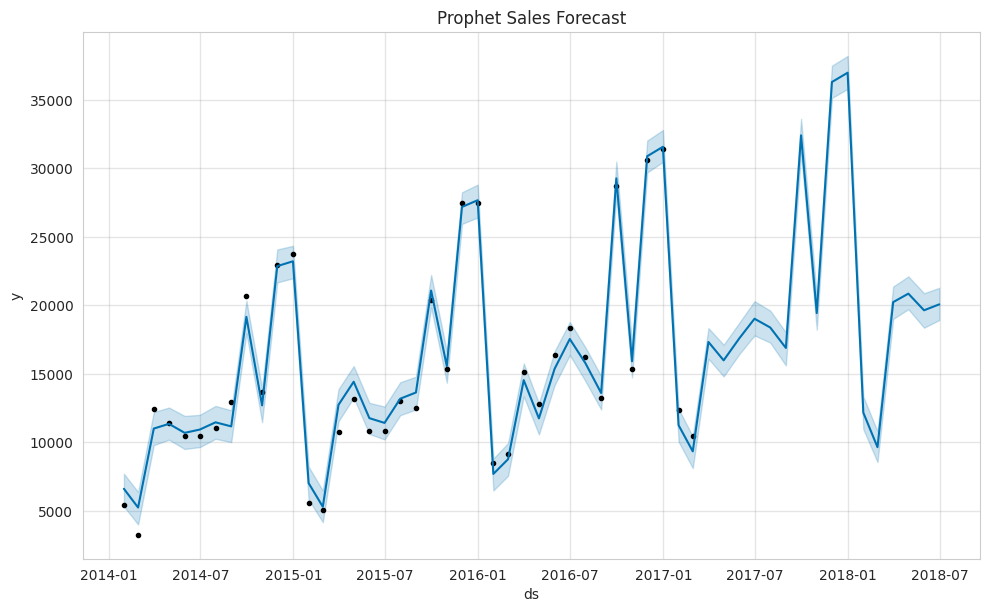

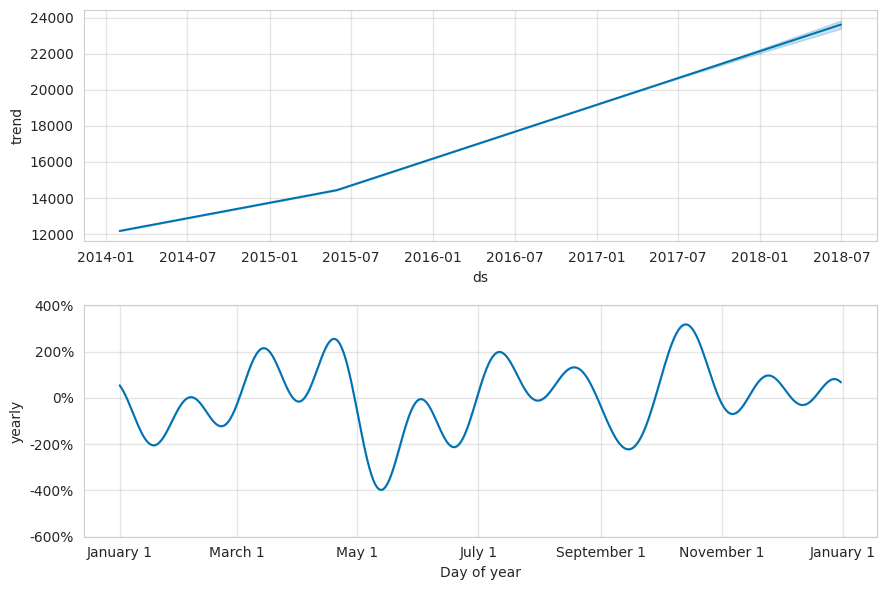

In [32]:
from prophet import Prophet

# Prepare data for Prophet
prophet_df = ts.rename(columns={'Date': 'ds', 'Sales': 'y'})

# Train-test split
train_size = int(len(prophet_df) * 0.8)
train = prophet_df[:train_size]
test = prophet_df[train_size:]

# Build model
m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
m.fit(train)

# Forecast future (including test period + 6 months beyond)
future = m.make_future_dataframe(periods=len(test) + 6, freq='M')
forecast = m.predict(future)

# Evaluate on test set
pred_test = forecast[['ds', 'yhat']].iloc[train_size:train_size + len(test)]
mae = mean_absolute_error(test['y'].values, pred_test['yhat'].values)
rmse = np.sqrt(mean_squared_error(test['y'].values, pred_test['yhat'].values))
print(f"Prophet MAE:  ${mae:,.2f}")
print(f"Prophet RMSE: ${rmse:,.2f}")

# Plot forecast
fig = m.plot(forecast)
plt.title('Prophet Sales Forecast')
plt.savefig('yearly_sales.png', dpi=150, bbox_inches='tight')
plt.show()

# Components (trend + seasonality)
fig2 = m.plot_components(forecast)
plt.savefig('yearly_sales.png', dpi=150, bbox_inches='tight')
plt.show()

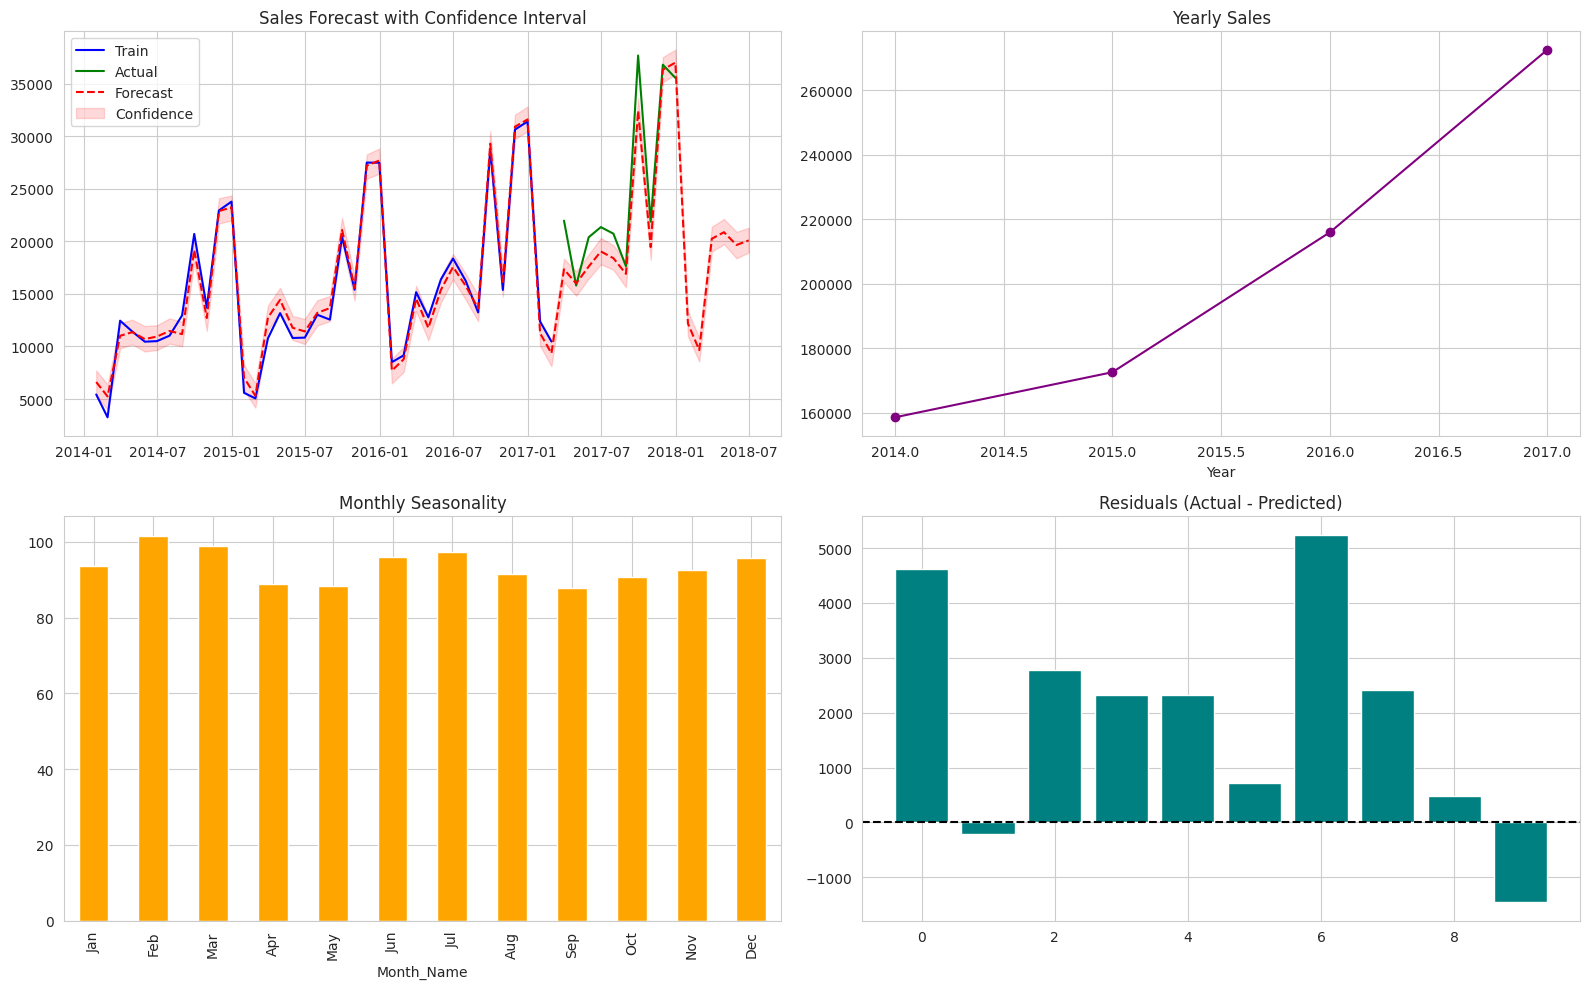

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Historical + Forecast
axes[0, 0].plot(train['ds'], train['y'], label='Train', color='blue')
axes[0, 0].plot(test['ds'], test['y'], label='Actual', color='green')
axes[0, 0].plot(forecast['ds'], forecast['yhat'], label='Forecast', color='red', linestyle='--')
axes[0, 0].fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                        color='red', alpha=0.15, label='Confidence')
axes[0, 0].set_title('Sales Forecast with Confidence Interval')
axes[0, 0].legend()

# 2. Yearly trend
yearly_sales.plot(x='Year', y='Sales', ax=axes[0, 1], marker='o', color='purple', legend=False)
axes[0, 1].set_title('Yearly Sales')

# 3. Seasonality
seasonality.plot(kind='bar', ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Monthly Seasonality')

# 4. Residuals
residuals = test['y'].values - pred_test['yhat'].values
axes[1, 1].bar(range(len(residuals)), residuals, color='teal')
axes[1, 1].axhline(0, color='black', linestyle='--')
axes[1, 1].set_title('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.savefig('yearly_sales.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# Save forecast to CSV
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    'outputs/predictions.csv', index=False
)

# --- Business Insights ---
next_6_months = forecast.tail(6)[['ds', 'yhat']].copy()
next_6_months['Month'] = next_6_months['ds'].dt.strftime('%B %Y')
next_6_months['yhat'] = next_6_months['yhat'].round(2)

print("\n===== BUSINESS INSIGHTS REPORT =====\n")
print("1. Next 6-Month Sales Forecast:")
print(next_6_months[['Month', 'yhat']].to_string(index=False))

best_month = seasonality.idxmax()
worst_month = seasonality.idxmin()
avg_growth = ((yearly_sales['Sales'].iloc[-1] / yearly_sales['Sales'].iloc[0]) ** (1/(len(yearly_sales)-1)) - 1) * 100

print(f"\n2. Peak Sales Month: {best_month}")
print(f"3. Lowest Sales Month: {worst_month}")
print(f"4. Avg Yearly Growth Rate: {avg_growth:.2f}%")
print(f"5. Model Accuracy (R²): {r2:.4f}" if 'r2' in dir() else "")
print(f"\n6. Recommendations:")
print("   - Stock up inventory before peak months.")
print("   - Plan marketing campaigns during low-sales months.")
print("   - Investigate drivers behind yearly growth/decline.")


===== BUSINESS INSIGHTS REPORT =====

1. Next 6-Month Sales Forecast:
        Month     yhat
 January 2018 12179.41
February 2018  9657.19
   March 2018 20246.32
   April 2018 20865.26
     May 2018 19650.23
    June 2018 20082.90

2. Peak Sales Month: Feb
3. Lowest Sales Month: Sep
4. Avg Yearly Growth Rate: 19.77%
5. Model Accuracy (R²): 0.6292

6. Recommendations:
   - Stock up inventory before peak months.
   - Plan marketing campaigns during low-sales months.
   - Investigate drivers behind yearly growth/decline.
